In [2]:
# impoting libraries 
import pandas as pd
import matplotlib.pyplot as plt 
from datasets import load_dataset
import ast

# loading dataset 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

<Axes: >

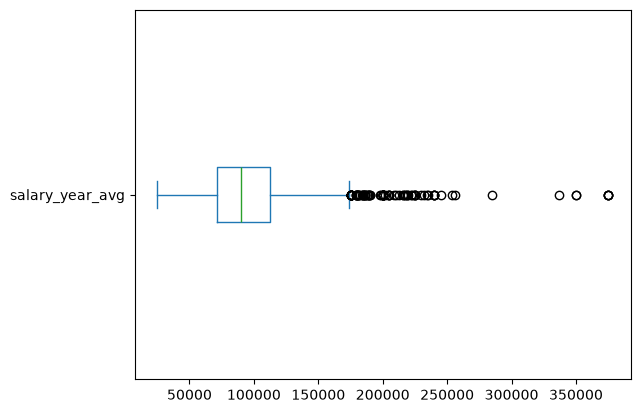

In [7]:
df_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States' )].copy()
df_DA = df_DA.dropna(subset='salary_year_avg')
df_DA['salary_year_avg'].plot(kind='box', vert = False)

C:\Users\arjun\AppData\Local\Temp\ipykernel_22812\654379395.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_DA['salary_year_avg'], vert=False)


{'whiskers': [<matplotlib.lines.Line2D at 0x1ff7992bad0>,
 'caps': [<matplotlib.lines.Line2D at 0x1ff7992a850>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ff79943d10>],
 'medians': [<matplotlib.lines.Line2D at 0x1ff79941550>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ff7992acd0>],
 'means': []}

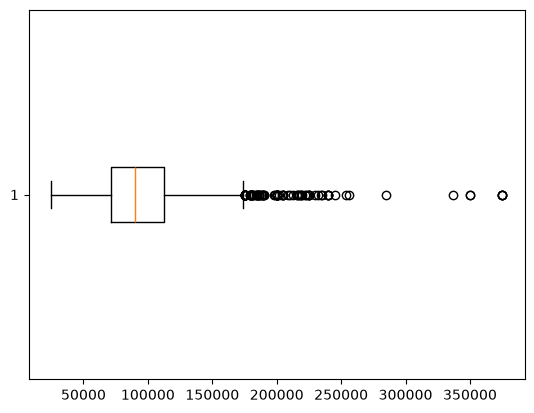

In [9]:
plt.boxplot(df_DA['salary_year_avg'], vert=False)

## Salary Distribution of Data Analyst, Data Engineer, Data Scientists

C:\Users\arjun\AppData\Local\Temp\ipykernel_22812\3920645480.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(box_list, tick_labels= job_list, vert=False)


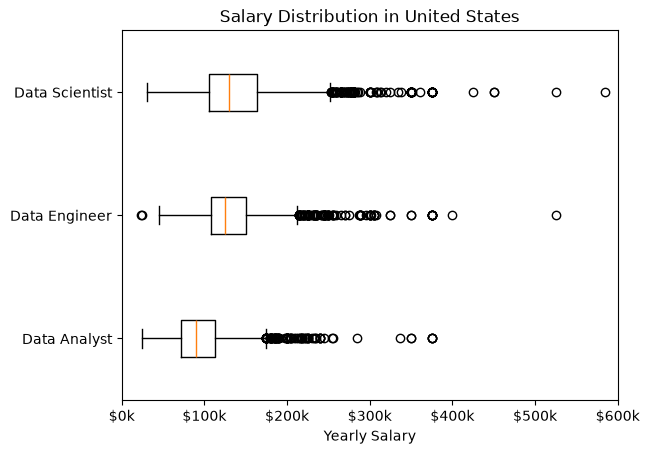

In [ ]:
job_list = ['Data Analyst','Data Engineer','Data Scientist']
df_US = df[(df['job_title_short'].isin(job_list)) & (df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset ='salary_year_avg')
box_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_list]



plt.boxplot(box_list, tick_labels= job_list, vert=False)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}k'))
plt.title('Salary Distribution in United States')
plt.xlim(0,600000)
plt.xlabel('Yearly Salary')
plt.ylabel('')
plt.show()

In [27]:
box_list

[                 salary_year_avg
 job_title_short                 
 Data Analyst             89000.0
 Data Analyst             90250.0
 Data Analyst            133285.0
 Data Analyst             62623.0
 Data Analyst             71300.0
 ...                          ...
 Data Analyst             70000.0
 Data Analyst            111175.0
 Data Analyst            125000.0
 Data Analyst            115000.0
 Data Analyst             87500.0
 
 [4350 rows x 1 columns],
                  salary_year_avg
 job_title_short                 
 Data Engineer           120000.0
 Data Engineer           129500.0
 Data Engineer           185000.0
 Data Engineer           195000.0
 Data Engineer            97500.0
 ...                          ...
 Data Engineer           125000.0
 Data Engineer            90000.0
 Data Engineer           217500.0
 Data Engineer           139216.0
 Data Engineer           150000.0
 
 [2915 rows x 1 columns],
                  salary_year_avg
 job_title_short          